<a href="https://colab.research.google.com/github/eospgonz10/DL_BrainTumor/blob/main/02%20-%20preprocesado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - Preprocesamiento de Imágenes

**Objetivo:** Crear pipeline de preprocesamiento

Este notebook realiza:
- Redimensionamiento a 380×380 (tamaño estándar de EfficientNet-B4)
- Normalización con `preprocess_input` de EfficientNet-B4
- Split 70/15/15 (train/validation/test)
- Data augmentation conservadora para imágenes médicas
- Creación de datasets tf.data optimizados

## SECCIÓN 1: Conceptos Teóricos y Requisitos

### EfficientNet-B4 Especificaciones:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| **Input Size** | 380×380 | Estándar para B4 (sin padding) |
| **Normalización** | ImageNet `preprocess_input` | Media y std de ImageNet (recomendado para transfer learning) |
| **Canales de entrada** | 3 (RGB) | EfficientNet espera 3 canales; usaremos expansión de grises |
| **Rango de valores** | [-1, 1] | Producido por `preprocess_input` |

### Pipeline Completo:

```
Imagen Original (256×256, escala grises)
    ↓
[Resize to 380×380]
    ↓
[Convert Grayscale → RGB (3 channels)]
    ↓
[Apply preprocess_input (ImageNet normalization)]
    ↓
Dataset Training/Validation/Test tf.data
    ↓
[Optional: Data Augmentation on training set only]
    ↓
Ready for EfficientNet-B4 Transfer Learning
```

## SECCIÓN 2: Importes y Configuración

In [ ]:
# Librerías de sistema
import os
import sys
from pathlib import Path
from collections import Counter
import random

# Librerías de datos
import numpy as np
import pandas as pd
from PIL import Image

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import efficientnet

# Configuración
import warnings
warnings.filterwarnings('ignore')

# Versiones
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pillow: {Image.__version__}")

# Configurar TensorFlow para CPU
tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(4)
print("\n✓ TensorFlow configurado para CPU")

TensorFlow: 2.21.0
Keras: 3.14.0
NumPy: 2.4.3
Pillow: 12.1.1

✓ TensorFlow configurado para CPU


## SECCIÓN 3: Cargar Dataset desde Notebook 01

Utilizamos las variables `data_dir`, `training_dir`, `testing_dir` del notebook de exploración

In [ ]:
import kagglehub

print("Descargando dataset desde Kaggle...")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

data_dir = Path(path)
print(f"✓ Dataset disponible en: {data_dir}")

# Buscar carpetas Training y Testing
training_dir = None
testing_dir = None

for root, dirs, files in os.walk(data_dir):
    if 'Training' in dirs:
        training_dir = Path(root) / 'Training'
    if 'Testing' in dirs:
        testing_dir = Path(root) / 'Testing'

if training_dir and training_dir.exists():
    print(f"✓ Carpeta Training: {training_dir}")
    classes = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
    print(f"  Clases: {classes}")

if testing_dir and testing_dir.exists():
    print(f"✓ Carpeta Testing: {testing_dir}")

Descargando dataset desde Kaggle...
✓ Dataset disponible en: C:\Users\estiv\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
✓ Carpeta Training: C:\Users\estiv\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Training
  Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']
✓ Carpeta Testing: C:\Users\estiv\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing


## SECCIÓN 4: Función de Preprocesamiento para EfficientNet-B4

In [ ]:
def load_and_preprocess_image(image_path, target_size=(380, 380)):
    """
    Carga y preprocesa imagen para EfficientNet-B4:

    Pasos:
    1. Leer imagen (PIL)
    2. Convertir a escala de grises si no lo está
    3. Redimensionar a 380×380 con LANCZOS
    4. Convertir a RGB (3 canales por replicación)
    5. Aplicar preprocess_input de EfficientNet-B4 (normalización ImageNet)

    Args:
        image_path: Ruta a la imagen
        target_size: Tamaño objetivo (default: 380×380 para EfficientNet-B4)

    Returns:
        numpy array de shape (380, 380, 3) con rango [-1, 1]
    """
    try:
        # Paso 1: Leer imagen
        img = Image.open(image_path)

        # Paso 2: Convertir a escala de grises
        if img.mode != 'L':
            img = img.convert('L')

        # Paso 3: Redimensionar
        img = img.resize(target_size, Image.LANCZOS)

        # Paso 4: Convertir a RGB (replicar canal gris en 3 canales)
        img_array = np.array(img, dtype=np.float32)
        img_rgb = np.stack([img_array, img_array, img_array], axis=-1)

        # Paso 5: Aplicar preprocess_input de EfficientNet-B4
        # Esto normaliza según estadísticas de ImageNet
        img_preprocessed = efficientnet.preprocess_input(img_rgb)

        return img_preprocessed

    except Exception as e:
        print(f"❌ Error procesando {image_path}: {str(e)}")
        return None

print("✓ Función load_and_preprocess_image definida")
print(f"  Target size: 380×380")
print(f"  Output channels: 3 (RGB)")
print(f"  Normalización: ImageNet preprocess_input ([-1, 1])")

✓ Función load_and_preprocess_image definida
  Target size: 380×380
  Output channels: 3 (RGB)
  Normalización: ImageNet preprocess_input ([-1, 1])


## SECCIÓN 5: Crear Split 70/15/15 (Train/Validation/Test)

In [ ]:
def create_stratified_split(training_dir, testing_dir,
                           train_pct=0.70, val_pct=0.15, test_pct=0.15,
                           random_state=42):
    """
    Crea split 70/15/15 estratificado por clase:
    - 70%: Training (para entrenar el modelo)
    - 15%: Validation (para validar durante entrenamiento)
    - 15%: Test (evaluación final, datos nunca vistos)

    El split se hace del conjunto TRAINING original de Kaggle.
    El TESTING set de Kaggle se puede utilizar después si necesario.

    Estratificación: Mantiene proporción de clases en cada split
    """

    random.seed(random_state)
    np.random.seed(random_state)

    # Obtener clases
    class_names = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    print(f"Clases: {class_names}")
    print(f"Mapeo: {class_to_idx}")

    # Recopilar todas las imágenes por clase
    all_images_by_class = {}

    for class_name in class_names:
        class_dir = training_dir / class_name
        image_files = sorted(
            list(class_dir.glob('*.jpg')) +
            list(class_dir.glob('*.png')) +
            list(class_dir.glob('*.jpeg'))
        )
        all_images_by_class[class_name] = image_files

    # Crear split estratificado
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    test_paths, test_labels = [], []

    for class_name, image_files in all_images_by_class.items():
        # Mezclar
        indices = list(range(len(image_files)))
        random.shuffle(indices)

        # Calcular split points
        n = len(image_files)
        train_end = int(n * train_pct)
        val_end = train_end + int(n * val_pct)

        # Asignar
        label = class_to_idx[class_name]

        for i in indices[:train_end]:
            train_paths.append(str(image_files[i]))
            train_labels.append(label)

        for i in indices[train_end:val_end]:
            val_paths.append(str(image_files[i]))
            val_labels.append(label)

        for i in indices[val_end:]:
            test_paths.append(str(image_files[i]))
            test_labels.append(label)

        print(f"\n{class_name}:")
        print(f"  Train: {train_end} | Val: {val_end - train_end} | Test: {n - val_end}")

    print(f"\n{'='*70}")
    print(f"SPLIT TOTAL:")
    print(f"  Train: {len(train_paths)} ({len(train_paths)/(len(train_paths)+len(val_paths)+len(test_paths))*100:.1f}%)")
    print(f"  Val:   {len(val_paths)} ({len(val_paths)/(len(train_paths)+len(val_paths)+len(test_paths))*100:.1f}%)")
    print(f"  Test:  {len(test_paths)} ({len(test_paths)/(len(train_paths)+len(val_paths)+len(test_paths))*100:.1f}%)")
    print(f"  TOTAL: {len(train_paths)+len(val_paths)+len(test_paths)}")

    return (
        train_paths, train_labels,
        val_paths, val_labels,
        test_paths, test_labels,
        class_names
    )

# Crear split
print("\n" + "="*70)
print("CREANDO SPLIT 70/15/15 ESTRATIFICADO")
print("="*70)

train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, class_names = \
    create_stratified_split(training_dir, testing_dir)


CREANDO SPLIT 70/15/15 ESTRATIFICADO
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']
Mapeo: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

glioma:
  Train: 979 | Val: 210 | Test: 211

meningioma:
  Train: 979 | Val: 210 | Test: 211

notumor:
  Train: 979 | Val: 210 | Test: 211

pituitary:
  Train: 979 | Val: 210 | Test: 211

SPLIT TOTAL:
  Train: 3916 (69.9%)
  Val:   840 (15.0%)
  Test:  844 (15.1%)
  TOTAL: 5600


## SECCIÓN 6: Definir Data Augmentation

In [ ]:
def create_augmentation_pipeline():
    """
    Crea pipeline de data augmentation conservador para imágenes médicas MRI.

    TÉCNICAS PERMITIDAS:
    • Rotación: ±10° (variación anatómica menor)
    • Zoom: 0.9-1.1 (ligero acercamiento/alejamiento)
    • Shift: ±5% (pequeños desplazamientos espaciales)

    TÉCNICAS NO PERMITIDAS:
    × Brightness/Contrast: Alterar intensidades destruye features médicas
    × Flip: Invierte anatomía (left-right flip destroye simetría cerebral)
    × Elastic deformation: No médicamente válida
    × Noise: Añade artefactos no presentes en MRI real
    """

    augmentation = keras.Sequential([
        layers.RandomRotation(
            factor=10/360,  # ±10 grados
            fill_mode='nearest',
            seed=42
        ),

        layers.RandomZoom(
            height_factor=0.1,  # ±10%
            width_factor=0.1,
            fill_mode='nearest',
            seed=42
        ),

        layers.RandomTranslation(
            height_factor=0.05,  # ±5%
            width_factor=0.05,
            fill_mode='nearest',
            seed=42
        ),
    ], name="MedicalImageAugmentation")

    return augmentation

# Crear augmentation
augmentation = create_augmentation_pipeline()

## SECCIÓN 7: Crear tf.data Datasets Optimizados

In [ ]:
def create_tf_dataset(image_paths, labels, class_names,
                      is_training=True,
                      batch_size=32,
                      augmentation=None,
                      shuffle_buffer=None):
    """
    Crea dataset tf.data optimizado para EfficientNet-B4.

    Características:
    - Carga lazy (bajo uso de RAM)
    - Preprocesamiento on-the-fly
    - Augmentation on-the-fly (solo en training)
    - Paralelización automática (AUTOTUNE)
    - Prefetching para pipelining
    - Batching eficiente

    Args:
        image_paths: Lista de rutas a imágenes
        labels: Lista de labels (índices de clase)
        class_names: Lista de nombres de clases
        is_training: Si es True, aplica augmentation y shuffle
        batch_size: Tamaño de batch
        augmentation: Pipeline de augmentation (None para no augmentar)
        shuffle_buffer: Tamaño del buffer de shuffle

    Returns:
        tf.data.Dataset
    """

    if shuffle_buffer is None:
        shuffle_buffer = len(image_paths) if is_training else 0

    def load_image_and_label(image_path, label):
        """Carga imagen y convierte label a one-hot"""
        # Cargar y preprocesar imagen
        image_str = image_path.numpy() if isinstance(image_path, tf.Tensor) else image_path
        image = load_and_preprocess_image(image_str, target_size=(380, 380))

        if image is None:
            # En caso de error, retornar imagen nula
            image = np.zeros((380, 380, 3), dtype=np.float32)

        # Convertir label a one-hot
        label_onehot = tf.keras.utils.to_categorical(label, num_classes=len(class_names))

        return image, label_onehot

    # Crear dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    # Map para cargar y preprocesar (paralelo)
    dataset = dataset.map(
        lambda img_path, label: tf.py_function(
            load_image_and_label,
            [img_path, label],
            [tf.float32, tf.float32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Establecer shapes
    dataset = dataset.map(
        lambda img, label: (
            tf.ensure_shape(img, (380, 380, 3)),
            tf.ensure_shape(label, (len(class_names),))
        )
    )

    # Augmentation (solo en training)
    if is_training and augmentation is not None:
        dataset = dataset.map(
            lambda img, label: (augmentation(img, training=True), label),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Shuffle (solo en training)
    if is_training and shuffle_buffer > 0:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Batch
    dataset = dataset.batch(batch_size)

    # Prefetch
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Configuración
BATCH_SIZE = 32  # Batch size conservador para CPU

print("\n" + "="*70)
print("CREANDO tf.data DATASETS")
print("="*70)

# Crear datasets
train_dataset = create_tf_dataset(
    train_paths, train_labels, class_names,
    is_training=True,
    batch_size=BATCH_SIZE,
    augmentation=augmentation,
    shuffle_buffer=len(train_paths)
)

val_dataset = create_tf_dataset(
    val_paths, val_labels, class_names,
    is_training=False,
    batch_size=BATCH_SIZE,
    augmentation=None,
    shuffle_buffer=0
)

test_dataset = create_tf_dataset(
    test_paths, test_labels, class_names,
    is_training=False,
    batch_size=BATCH_SIZE,
    augmentation=None,
    shuffle_buffer=0
)

print(f"\n✓ Datasets creados:")
print(f"  Train: {len(train_paths)} imágenes → {len(train_paths)//BATCH_SIZE} batches")
print(f"  Val:   {len(val_paths)} imágenes → {len(val_paths)//BATCH_SIZE} batches")
print(f"  Test:  {len(test_paths)} imágenes → {len(test_paths)//BATCH_SIZE} batches")


CREANDO tf.data DATASETS

✓ Datasets creados:
  Train: 3916 imágenes → 122 batches
  Val:   840 imágenes → 26 batches
  Test:  844 imágenes → 26 batches


## SECCIÓN 8: Visualizar Batch Preprocesado


Batch shape:
  Imágenes: (32, 380, 380, 3)
  Labels: (32, 4)

Rango de valores (después preprocess_input):
  Min: 0.0000
  Max: 255.0000
  Mean: 52.9806


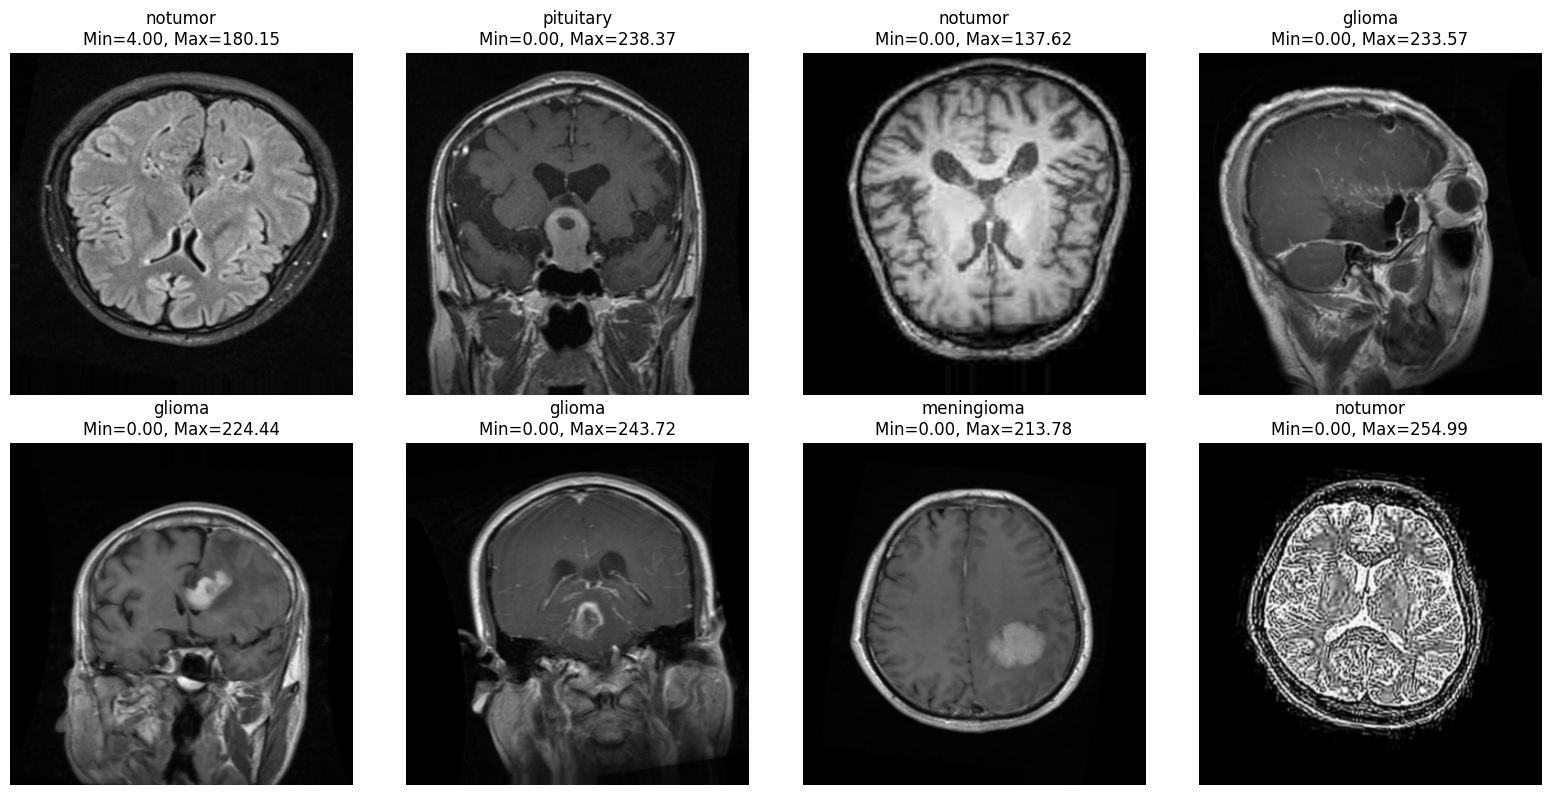


✓ Visualización guardada como 'batch_preprocesado_efficientnet.png'


In [ ]:
# Tomar un batch
sample_batch_images, sample_batch_labels = next(iter(train_dataset))

print(f"\nBatch shape:")
print(f"  Imágenes: {sample_batch_images.shape}")
print(f"  Labels: {sample_batch_labels.shape}")
print(f"\nRango de valores (después preprocess_input):")
print(f"  Min: {sample_batch_images.numpy().min():.4f}")
print(f"  Max: {sample_batch_images.numpy().max():.4f}")
print(f"  Mean: {sample_batch_images.numpy().mean():.4f}")

# Visualizar
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, len(sample_batch_images))):
    # Obtener imagen (canal rojo, ya que RGB son iguales para imágenes en escala gris)
    img = sample_batch_images[i].numpy()[:, :, 0]

    # Obtener label
    label_onehot = sample_batch_labels[i].numpy()
    label_idx = np.argmax(label_onehot)
    label_name = class_names[label_idx]

    # Normalizar para visualización (de [-1, 1] a [0, 1])
    img_display = (img + 1) / 2

    axes[i].imshow(img_display, cmap='gray')
    axes[i].set_title(f"{label_name}\nMin={img.min():.2f}, Max={img.max():.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('batch_preprocesado_efficientnet.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Visualización guardada como 'batch_preprocesado_efficientnet.png'")

## SECCIÓN 9: Guardar Información del Pipeline para Notebook 03

In [ ]:
# Información del pipeline
pipeline_info = {
    'input_size': (380, 380, 3),
    'normalization': 'EfficientNet-B4 preprocess_input (ImageNet)',
    'output_range': '[-1, 1]',
    'batch_size': BATCH_SIZE,
    'num_classes': len(class_names),
    'class_names': class_names,
    'splits': {
        'train': len(train_paths),
        'val': len(val_paths),
        'test': len(test_paths)
    },
    'augmentation': [
        'Rotation: ±10°',
        'Zoom: 0.9-1.1',
        'Shift: ±5%'
    ]
}

# Mostrar
print("\n" + "="*70)
print("INFORMACIÓN DEL PIPELINE")
print("="*70)
print(f"\nInput: {pipeline_info['input_size']}")
print(f"Normalización: {pipeline_info['normalization']}")
print(f"Rango: {pipeline_info['output_range']}")
print(f"\nClases ({pipeline_info['num_classes']}): {pipeline_info['class_names']}")
print(f"\nSplit:")
for split, count in pipeline_info['splits'].items():
    pct = count / sum(pipeline_info['splits'].values()) * 100
    print(f"  {split.upper()}: {count} ({pct:.1f}%)")
print(f"\nAugmentation: {', '.join(pipeline_info['augmentation'])}")


INFORMACIÓN DEL PIPELINE

Input: (380, 380, 3)
Normalización: EfficientNet-B4 preprocess_input (ImageNet)
Rango: [-1, 1]

Clases (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

Split:
  TRAIN: 3916 (69.9%)
  VAL: 840 (15.0%)
  TEST: 844 (15.1%)

Augmentation: Rotation: ±10°, Zoom: 0.9-1.1, Shift: ±5%


## SECCIÓN 10: Resumen del Preprocesamiento

In [ ]:
print("\n" + "="*70)
print("RESUMEN - FASE 2: PREPROCESAMIENTO")
print("="*70)

summary = f"""
📊 PREPROCESAMIENTO COMPLETADO

1. CONFIGURACIÓN PARA EFFICIENTNET-B4:
   ✓ Input Size: 380×380 (estándar para B4)
   ✓ Canales: 3 RGB (replicación de canal gris)
   ✓ Normalización: ImageNet preprocess_input ([-1, 1])
   ✓ Método de redimensionamiento: LANCZOS

2. PIPELINE DE PROCESAMIENTO:
   Imagen Original (escala gris)
   → Resize a 380×380
   → Conversión a RGB (3 canales)
   → Normalización ImageNet
   → Ready para Transfer Learning

3. SPLIT DE DATOS (Estratificado 70/15/15):
   • Training (70%): {len(train_paths)} imágenes
     {len(train_paths)//BATCH_SIZE} batches de {BATCH_SIZE}
   • Validation (15%): {len(val_paths)} imágenes
     {len(val_paths)//BATCH_SIZE} batches de {BATCH_SIZE}
   • Test (15%): {len(test_paths)} imágenes
     {len(test_paths)//BATCH_SIZE} batches de {BATCH_SIZE}
ESTADO: ✓ PREPROCESAMIENTO COMPLETADO - LISTO PARA ENTRENAMIENTO
"""

print(summary)

# Guardar
with open('resumen_preprocesado.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✓ Resumen guardado en 'resumen_preprocesado.txt'")


RESUMEN - FASE 2: PREPROCESAMIENTO

📊 PREPROCESAMIENTO COMPLETADO

1. CONFIGURACIÓN PARA EFFICIENTNET-B4:
   ✓ Input Size: 380×380 (estándar para B4)
   ✓ Canales: 3 RGB (replicación de canal gris)
   ✓ Normalización: ImageNet preprocess_input ([-1, 1])
   ✓ Método de redimensionamiento: LANCZOS

2. PIPELINE DE PROCESAMIENTO:
   Imagen Original (escala gris)
   → Resize a 380×380
   → Conversión a RGB (3 canales)
   → Normalización ImageNet
   → Ready para Transfer Learning

3. SPLIT DE DATOS (Estratificado 70/15/15):
   • Training (70%): 3916 imágenes
     122 batches de 32
   • Validation (15%): 840 imágenes
     26 batches de 32
   • Test (15%): 844 imágenes
     26 batches de 32
ESTADO: ✓ PREPROCESAMIENTO COMPLETADO - LISTO PARA ENTRENAMIENTO


✓ Resumen guardado en 'resumen_preprocesado.txt'
